# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

In [3]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model.

In [4]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. This gives us the ability to see how well our model is able to generalise to new data, which is critical.
We will use a 75-25% split between train and test respectively.

In [5]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training



In [7]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluation



In [13]:
y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:,1]

#### Accuracy

In [30]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)


Accuracy: 0.9036144578313253
Model Accuracy: 90.36%


#### Confusion Matrix

In [19]:
print(confusion_matrix(
    y_test,
    y_pred
))

[[3283    3]
 [ 349   17]]


#### Classification Report

In [32]:
print(classification_report(
    y_test,
    y_pred
))


              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.85      0.05      0.09       366

    accuracy                           0.90      3652
   macro avg       0.88      0.52      0.52      3652
weighted avg       0.90      0.90      0.86      3652



#### ROC-AUC Score

In [21]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC:", roc_auc)

ROC AUC: 0.6614645174593988


### Feature Importance

In [24]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                    Feature  Importance
0                  cons_12m    0.050988
14               net_margin    0.049382
5   forecast_meter_rent_12m    0.048788
3         forecast_cons_12m    0.047018
11     margin_gross_pow_ele    0.046856
12       margin_net_pow_ele    0.046673
2           cons_last_month    0.036467
15                  pow_max    0.035107
10                 imp_cons    0.031671
49             months_activ    0.031448


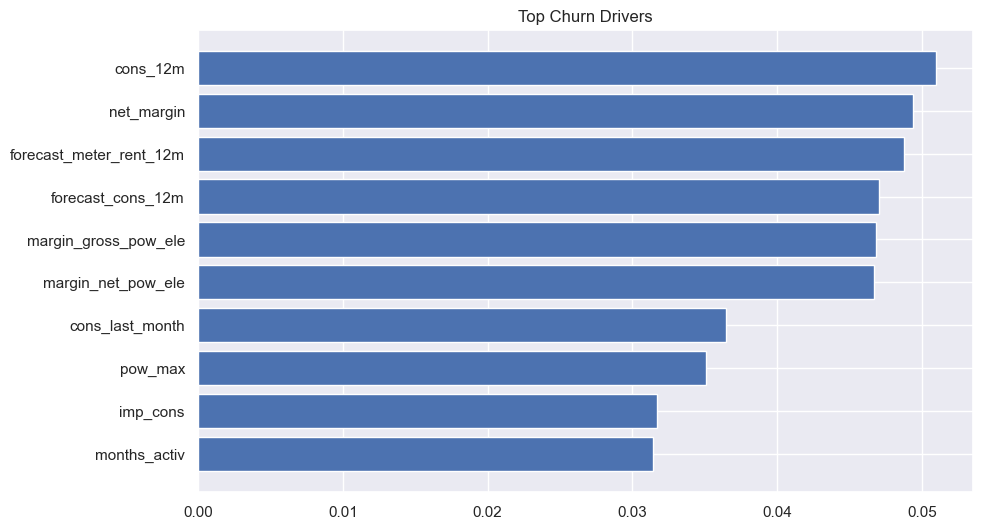

In [29]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title("Top Churn Drivers")

plt.gca().invert_yaxis()

plt.show()

### Business Interpretation:

Finding 1:
Customers with low margins are more likely to churn.

Finding 2:
Customers showing decreasing energy consumption have higher churn risk.

Finding 3:
Customers with high price sensitivity are more likely to switch providers.

Finding 4:
Long-tenure customers are less likely to churn.

### Recommendation:

* Identify customers with high churn probability.
* Offer targeted retention discounts only to those customers.
* Monitor churn reduction and retrain the model periodically.
* Offer loyalty incentives for long-term contracts.
* Improve customer engagement through proactive account management.
* Introduce more stable and predictable pricing plans.


### Business Impact:
* Improved customer retention.
* Reduced revenue loss from churn. 
* More efficient use of retention budgets. 
* Data-driven decision-making for customer engagement.